In [1]:
import re
import os

In [ ]:
regex = re.compile(".*\.wav")
wav_files = [1 if regex.match(f) is not None else 0 for _, _, files_list in os.walk("../data/dataset") for f in files_list]
sum(wav_files)

64727

In [1]:
import librosa
from librosa.feature import melspectrogram
import torch
import matplotlib.pyplot as plt
import torchaudio
import torchaudio.transforms as T
import torchvision.transforms as transforms

(13654,) 16000
torch.Size([128, 107])
torch.Size([128, 107])
torch.Size([1, 128, 128])


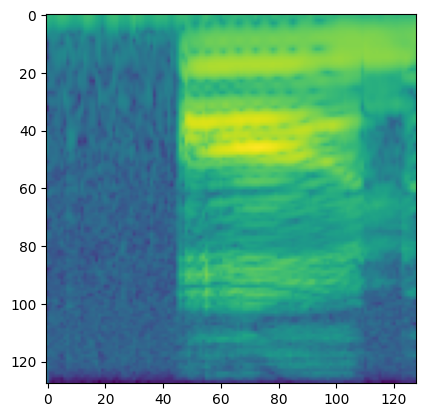

In [3]:
X_np, sr = librosa.load("../data/audio_dataset/train/on/on_0a9f9af7_nohash_0.wav", sr=None)
print(X_np.shape, sr)
X = torch.tensor(X_np)
mel_spec = T.MelSpectrogram(sample_rate=sr, n_fft=2048, n_mels=128, win_length=256)
mel_specgram = mel_spec(torch.nn.functional.normalize(X, p=2, dim=0))
print(mel_specgram.shape)
mel_specgram: torch.Tensor = T.AmplitudeToDB()(mel_specgram)
print(mel_specgram.shape)
mel_specgram = transforms.Resize((128, 128))(mel_specgram.unsqueeze(0))
print(mel_specgram.shape)
plt.imshow(mel_specgram.squeeze(0))

torch.Size([1, 116, 116])


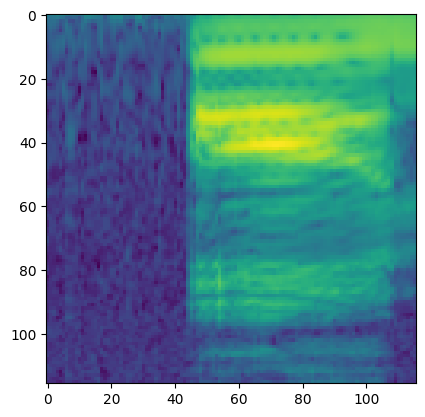

In [ ]:
crop = transforms.RandomCrop(size=(116, 116))(mel_specgram)
print(crop.shape)
plt.imshow(crop.squeeze(0))

In [16]:
from PIL.Image import Image
import torchvision.transforms.functional as FV

plt.imsave("../data/xd.png", mel_specgram.squeeze(0))

In [10]:
mel_specgram.shape


torch.Size([128, 81])

(16000,) 16000


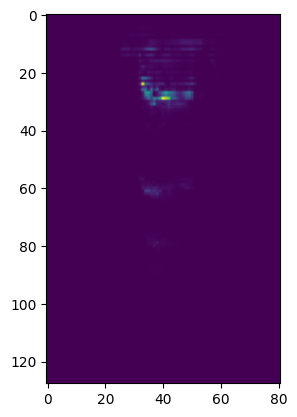

In [77]:
X_np, sr = librosa.load("../data/dataset/train/bed/fffcabd1_nohash_0.wav", sr=None)
print(X_np.shape, sr)
X = torch.tensor(X_np)
mel_spec = T.MelSpectrogram(sample_rate=sr, n_fft=400, n_mels=128)
mel_specgram = mel_spec(torch.nn.functional.normalize(X, p=2, dim=0))
plt.imshow(mel_specgram)

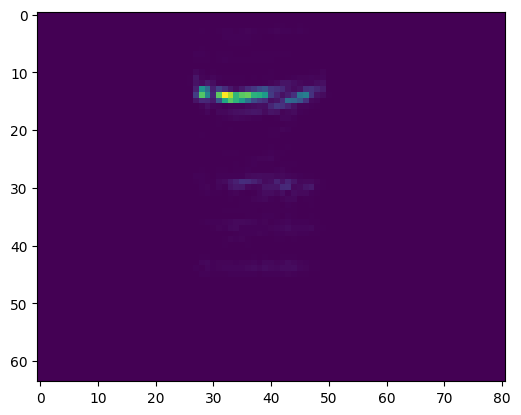

In [46]:

mel_specgram = mel_spec(X)
plt.imshow(mel_specgram)

In [47]:
torch.mean(X), torch.std(X)

(tensor(-0.0013), tensor(0.2810))

In [50]:
X_norm = torch.nn.functional.normalize(X, p=2, dim=0)
torch.mean(X_norm), torch.std(X_norm)**2

(tensor(-3.7485e-05), tensor(6.2502e-05))

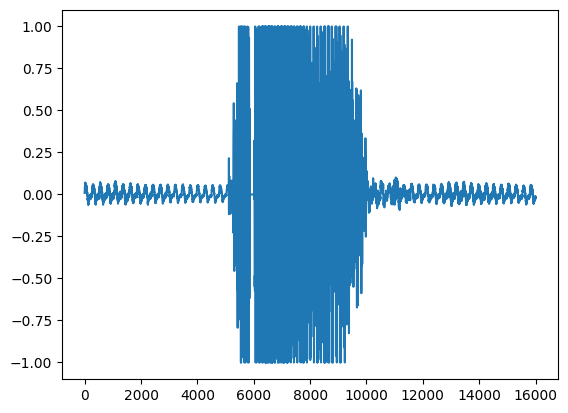

In [56]:
plt.plot(X_np)

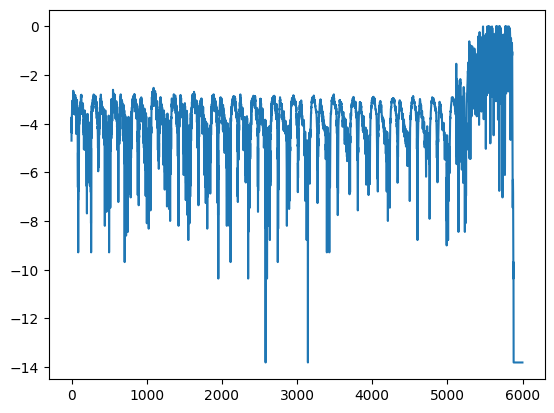

In [70]:
plt.plot(torch.log(torch.abs(X[:6000]) + 1e-6))

In [62]:
X_np[5000:5500]

array([-5.37109375e-03, -8.08715820e-03, -6.92749023e-03, -9.76562500e-04,
       -4.57763672e-03, -2.44140625e-03,  3.41796875e-03,  1.52587891e-04,
       -3.26538086e-03, -1.34277344e-03, -1.52587891e-04, -3.17382812e-03,
       -2.96020508e-03, -4.27246094e-03, -3.41796875e-03,  1.25122070e-03,
       -2.50244141e-03, -3.57055664e-03, -7.62939453e-04, -3.08227539e-03,
       -6.16455078e-03, -6.74438477e-03, -7.17163086e-03, -4.88281250e-03,
       -5.61523438e-03, -7.17163086e-03, -4.51660156e-03, -4.73022461e-03,
       -2.38037109e-03,  2.71606445e-03,  4.18090820e-03,  4.27246094e-03,
        7.84301758e-03,  8.91113281e-03,  1.01013184e-02,  1.57165527e-02,
        1.75476074e-02,  2.03857422e-02,  2.38647461e-02,  2.26440430e-02,
        2.38342285e-02,  2.68249512e-02,  2.85034180e-02,  3.08837891e-02,
        3.01818848e-02,  2.98461914e-02,  3.33251953e-02,  3.50952148e-02,
        3.57971191e-02,  3.68347168e-02,  3.84216309e-02,  4.04663086e-02,
        4.26330566e-02,  

In [ ]:

mel_specgram.shape

torch.Size([128, 81])

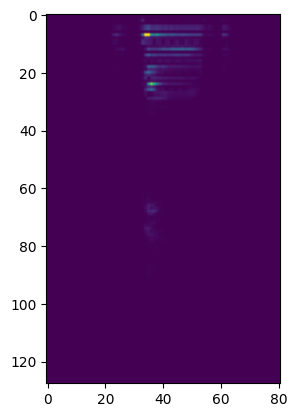

In [11]:
X

array([0.00875854, 0.0090332 , 0.00906372, ..., 0.00946045, 0.00897217,
       0.0088501 ], dtype=float32)

0 0.0005
1 0.00055
2 0.0006
3 0.0006499999999999999
4 0.0006999999999999998
5 0.0007499999999999997
6 0.0007999999999999996
7 0.0008499999999999996
8 0.0008999999999999997
9 0.0009499999999999997
10 0.001
11 0.00095
12 0.0009025
13 0.000857375
14 0.0008145062499999999
15 0.0007737809374999998
16 0.0007350918906249997
17 0.0006983372960937497
18 0.0006634204312890621
19 0.000630249409724609


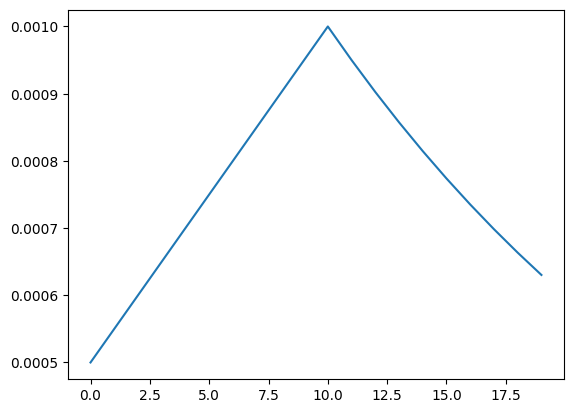

In [18]:
import torch
from torch.optim.lr_scheduler import LinearLR, ExponentialLR, SequentialLR, ConstantLR
import matplotlib.pyplot as plt

optim = torch.optim.Adam([torch.nn.Parameter(torch.randn(2, 3))], lr=0.001)
scheduler1 = LinearLR(optim, start_factor=0.5, end_factor=1.0, total_iters=10)
scheduler2 = ExponentialLR(optim, gamma=0.95)
scheduler = SequentialLR(optim, schedulers=[scheduler1, scheduler2], milestones=[10])

vals = []

for i in range(20):
    vals.append( scheduler.get_last_lr()[0])
    print(i, scheduler.get_last_lr()[0])
    optim.step()
    scheduler.step()

plt.plot(vals)

In [4]:
from torchvision.datasets import ImageFolder

ds = ImageFolder("../data/image_dataset/valid")
[(img[0], ds.classes[img[1]]) for img in ds.imgs]

[('../data/image_dataset/valid\\down\\0_audio_0.png', 'down'),
 ('../data/image_dataset/valid\\down\\0_audio_1.png', 'down'),
 ('../data/image_dataset/valid\\down\\0_audio_10.png', 'down'),
 ('../data/image_dataset/valid\\down\\0_audio_100.png', 'down'),
 ('../data/image_dataset/valid\\down\\0_audio_101.png', 'down'),
 ('../data/image_dataset/valid\\down\\0_audio_102.png', 'down'),
 ('../data/image_dataset/valid\\down\\0_audio_103.png', 'down'),
 ('../data/image_dataset/valid\\down\\0_audio_104.png', 'down'),
 ('../data/image_dataset/valid\\down\\0_audio_105.png', 'down'),
 ('../data/image_dataset/valid\\down\\0_audio_106.png', 'down'),
 ('../data/image_dataset/valid\\down\\0_audio_107.png', 'down'),
 ('../data/image_dataset/valid\\down\\0_audio_108.png', 'down'),
 ('../data/image_dataset/valid\\down\\0_audio_109.png', 'down'),
 ('../data/image_dataset/valid\\down\\0_audio_11.png', 'down'),
 ('../data/image_dataset/valid\\down\\0_audio_110.png', 'down'),
 ('../data/image_dataset/valid\

In [21]:
import torch
from models.simple_transformer import SimpleTransformer
import torchvision.transforms as T
import torch.nn.functional as F

loaded_model = torch.load('..\\mlartifacts\\227019510024899769\\d7ea781d0b0746b98fa0325f6180fbbf\\artifacts\\model_checkpoint_epoch_12\\data\\model.pth')
ds = ImageFolder("../data/image_dataset/valid", transform=T.ToTensor(), target_transform=T.Lambda(lambda x: print("KUTAS", x)))
image, label = next(iter(ds))
print(image.shape, label)
y_pred = loaded_model(image.unsqueeze(0).cuda())
F.softmax(y_pred, dim=-1)

KUTAS 0
torch.Size([3, 128, 128]) None


C:\Users\waxer\AppData\Local\Temp\ipykernel_20484\3337359591.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model = torch.load('..\\mlartifacts\\2270195100248997

tensor([[9.9235e-01, 4.5227e-03, 4.1610e-05, 1.6143e-03, 5.8287e-05, 2.9395e-04,
         1.9252e-04, 7.2071e-04, 1.1494e-05, 5.9233e-05, 1.3523e-04]],
       device='cuda:0', grad_fn=<SoftmaxBackward0>)